In [ ]:
import pandas as pd

site_number = '90069'
bisection = pd.read_csv(f'output_site_{site_number}_bisection.csv')
data_49 = pd.read_csv(f'output_site_{site_number}_49.csv')
data_60 = pd.read_csv(f'output_site_{site_number}_60.csv')
#nonlinear = pd.read_csv(f'output_site_{site_number}_nonlinear.csv')
#load_shift = pd.read_csv(f'output_site_{site_number}_load_shifting.csv')
bisection 


,Hot Water Outlet Temperature (C),T_WH3,T_WH10,Water Heating Heat Pump COP (-),Water Heating Mode,Water Heating Electric Power (kWh),Hot Water Delivered (kWh),Hot Water Heat Loss (kWh),Hot Water Heat Injected (kWh),Hot Water Unmet Demand (kWh),Draw Data,Setpoints
0,50.793497,50.867732,50.867732,4.423562,Off,0.000250,0.000000,0.016759,0.000000,0.0,0.00000,49.000000
1,50.727607,50.784989,50.785739,4.432140,Off,0.000250,0.000000,0.016705,0.000000,0.0,11.35623,49.000000
2,50.577555,50.703067,50.102594,4.726416,Off,0.000250,0.442776,0.015326,0.000000,0.0,0.00000,49.000000
3,50.542241,50.600156,49.957227,4.739075,Off,0.000250,0.000000,0.014539,0.000000,0.0,0.00000,49.000000
4,50.473902,50.518395,49.811978,4.751206,Off,0.000250,0.000000,0.014504,0.000000,0.0,0.00000,49.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
19098,49.040269,49.146577,41.066962,5.394600,Off,0.000250,0.000000,0.012373,0.000000,0.0,0.00000,49.000000
19099,48.888864,49.066735,40.981354,5.403434,Off,0.000250,0.000000,0.012342,0.000000,0.0,0.00000,49.000000
19100,50.692876,50.692876,49.748751,4.809220,Heat Pump On,0.128666,0.000000,0.013205,0.610787,0.0,0.00000,59.656250
19101,50.673273,50.747219,50.202146,4.782418,Off,0.000250,0.000000,0.014056,0.000000,0.0,0.00000,49.333008


In [ ]:
#Comparing heat loss 
import pandas as pd
import numpy as np

def get_daily_kWh(data):
    energy = data["Water Heating Electric Power (kWh)"] #15 minute intervals of kwh
    day_sums = energy.groupby(energy.index // 96).sum().tolist()
    return (np.mean(day_sums))

def return_unmet_draws(data, min = 40.6):
    #data["Hot Water Outlet Temperature (C)"] = (pd.to_numeric(data["Hot Water Outlet Temperature (C)"], errors="coerce"))
    draws = data["Hot Water Outlet Temperature (C)"].values
    cold_water_draws = sum(float(i) < min for i in draws)
    return cold_water_draws/len(draws) * 100

dt = 1 # seconds in each 15-minute interval
#E_electric = E_delivered + E_loss + other
def total_loss_kWh(data):
    # 15-minute intervals
    return np.sum(data["Hot Water Heat Loss (kWh)"]*dt) 

def total_electric_kWh(data):
    return np.sum(data["Hot Water Heat Injected (kWh)"]*dt)

def total_heat_pump_electric_kWh(data):
    return np.sum(data["Water Heating Electric Power (kWh)"]*dt)
#sites = [22096]

sites = [ 90069
]


unmet_draws = []
daily_kWh = []
net_savings = []
avg_draw = []
net_injection_savings = []
net_loss_savings = []

for site_number in sites:
    print(site_number)
    #Comparing standard performance to 40 G bisection controller

    min_temp = 40.6

    elevated = pd.read_csv(f'output_site_{site_number}_60.csv')

    baseline_og = None
 
    bisection = pd.read_csv(f"output_site_90069_bisection.csv")

    print("Bisection", return_unmet_draws(bisection, min_temp), get_daily_kWh(bisection), np.sum(bisection["Water Heating Electric Power (kWh)"])) #100 days
    print("Baseline (Elevated) ", return_unmet_draws(elevated, min_temp), get_daily_kWh(elevated), np.sum(elevated["Water Heating Electric Power (kWh)"])) #365 days
    print("Net savings: ", 1 - np.sum(bisection["Water Heating Electric Power (kWh)"])/np.sum(elevated["Water Heating Electric Power (kWh)"]))
    draw = elevated['Draw Data']
    draw = draw[:-95] #removing last day to keep indices exact
    daily_avg = np.sum(np.asarray(draw).reshape(-1, 96), axis=1)
    avg_draw.append(daily_avg.mean()) #avg L per day
    unmet_draws.append([return_unmet_draws(elevated, min_temp), return_unmet_draws(bisection, min_temp) ])
    daily_kWh.append([get_daily_kWh(elevated),get_daily_kWh(bisection)  ])
    net_savings.append(np.sum(elevated["Water Heating Electric Power (kWh)"]) - np.sum(bisection["Water Heating Electric Power (kWh)"]) )
    #print(return_unmet_draws(bisection_ideal, min_temp), get_daily_kWh(bisection_ideal), np.sum(bisection_ideal["Water Heating Electric Power"])) #100 days
 

    #Compute total loss and kwh of elevated and bisection
    elevated_loss_kWh   = total_loss_kWh(elevated)
    bisection_loss_kWh  = total_loss_kWh(bisection)
    elevated_delivered = np.sum(elevated["Hot Water Delivered (kWh)"]*dt) 
    bisection_delivered = np.sum(bisection["Hot Water Delivered (kWh)"]*dt) 

    elevated_elec_kWh  = total_electric_kWh(elevated)
    bisection_elec_kWh = total_electric_kWh(bisection)

    # Absolute savings
    total_savings_kWh = elevated_elec_kWh - bisection_elec_kWh
    loss_savings_kWh  = elevated_loss_kWh - bisection_loss_kWh

    net_injection_savings.append(elevated_elec_kWh - bisection_elec_kWh)
    net_loss_savings.append((elevated_loss_kWh - bisection_loss_kWh))

    print("Elevated Electric = ", elevated_elec_kWh, " (Injected) ~ ", elevated_delivered, " (delivered) + ", elevated_loss_kWh, "(loss) = ", elevated_delivered + elevated_loss_kWh, " unaccounted: ", elevated_elec_kWh - (elevated_delivered + elevated_loss_kWh))
    print("Bisection Electric = ", bisection_elec_kWh, " (Injected) ~ ", bisection_delivered, " (delivered) + ", bisection_loss_kWh, "(loss) = ", bisection_delivered + bisection_loss_kWh, " unaccounted: ", bisection_elec_kWh - (bisection_delivered + bisection_loss_kWh))
    print(f"Difference in Losses (kWh): {total_savings_kWh:.2f}")
    print(f"Difference in Electric (kWh): {loss_savings_kWh:.2f}")
    print(f"Injection Savings (kWh): {(1 - bisection_elec_kWh/elevated_elec_kWh)* 100} %")
    print(f"Electric Savings (kWh): {(1 - total_heat_pump_electric_kWh(bisection)/total_heat_pump_electric_kWh(elevated))* 100} %")
    print(f"Loss Savings (kWh): {(1 - bisection_loss_kWh/elevated_loss_kWh) * 100} %")






90069
Bisection 0.015704339632518452 1.297863495022236 258.2748355094249
Baseline (Elevated)  0.0 1.583782341628132 315.1726859839982
Net savings:  0.18052912896602358
Elevated Electric =  1450.3610345239094  (Injected) ~  1129.521327764081  (delivered) +  321.4033448138807 (loss) =  1450.9246725779617  unaccounted:  -0.5636380540522623
Bisection Electric =  1363.4834059024784  (Injected) ~  1129.5208965944955  (delivered) +  234.5707527678287 (loss) =  1364.0916493623242  unaccounted:  -0.6082434598458804
Difference in Losses (kWh): 86.88
Difference in Electric (kWh): 86.83
Injection Savings (kWh): 5.990069131300757 %
Electric Savings (kWh): 18.052912896602358 %
Loss Savings (kWh): 27.016704538758084 %


In [ ]:
print(sum(bisection['Water Heating Electric Power (kWh)']))
print(sum(data_49['Water Heating Electric Power (kWh)']))
print(sum(data_60['Water Heating Electric Power (kWh)']))

print(sum(bisection['Hot Water Unmet Demand (kWh)']))
print(sum(data_49['Hot Water Unmet Demand (kWh)']))
print(sum(data_60['Hot Water Unmet Demand (kWh)']))



258.274835509425
250.4712484292244
315.1726859839983
0.0007368650770781
0.0266461239946396
0.0
0.015704339632518452
0.031408679265036904
0.0


In [ ]:
import 

,Hot Water Outlet Temperature (C),T_WH3,T_WH10,Water Heating Heat Pump COP (-),Water Heating Mode,Water Heating Electric Power (kWh),Hot Water Delivered (kWh),Hot Water Heat Loss (kWh),Hot Water Heat Injected (kWh),Hot Water Unmet Demand (kWh),Draw Data,Setpoints
0,50.844331,50.899874,50.899874,4.420265,Off,0.00025,0.000000,0.016769,0.0,0.0,0.00000,49.0
1,50.830502,50.851936,50.852182,4.425321,Off,0.00025,0.000000,0.016735,0.0,0.0,11.35623,49.0
2,50.711143,50.803635,50.662358,4.571044,Off,0.00025,0.442776,0.015796,0.0,0.0,0.00000,49.0
3,50.605184,50.755353,50.585712,4.579538,Off,0.00025,0.000000,0.015254,0.0,0.0,0.00000,49.0
4,50.633468,50.684711,50.508097,4.588352,Off,0.00025,0.000000,0.015237,0.0,0.0,0.00000,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9594,52.389041,52.468046,33.455412,5.923056,Off,0.00025,0.000000,0.011855,0.0,0.0,0.00000,51.5
9595,52.358782,52.417282,33.404332,5.926088,Off,0.00025,0.000000,0.011841,0.0,0.0,0.00000,51.5
9596,52.246356,52.366200,33.354040,5.929093,Off,0.00025,0.000000,0.011825,0.0,0.0,0.00000,51.5
9597,52.263942,52.263942,33.304524,5.932071,Off,0.00025,0.000000,0.011809,0.0,0.0,0.00000,51.5


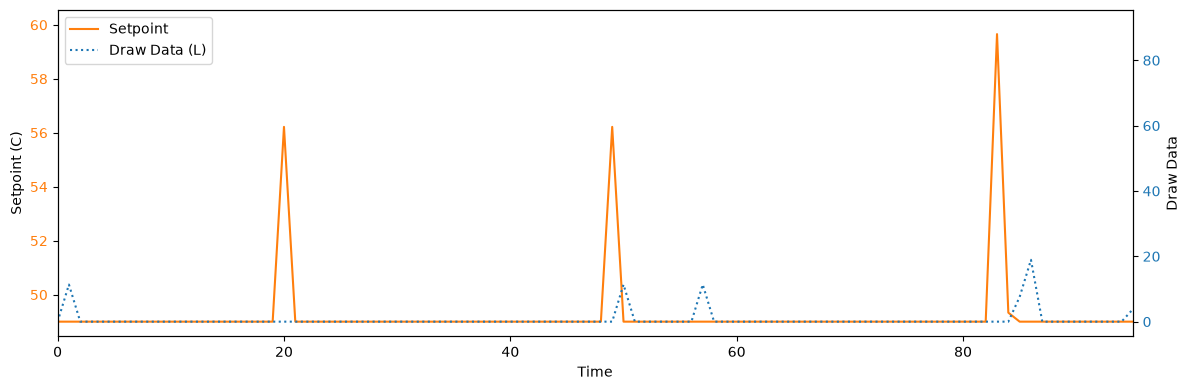

In [8]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(bisection['Setpoints'], label='Setpoint', color='tab:orange')
ax1.set_ylabel('Setpoint (C)')
# ax1.plot(bisection['Water Heating Electric Power (kWh)'], label='KWh', color='tab:orange')
# ax1.set_ylabel('Water Heating Electric Power (kWh)')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='tab:orange')

ax2 = ax1.twinx()
ax2.plot(bisection['Draw Data'], label='Draw Data (L)', linestyle='dotted', color='tab:blue')
ax2.set_ylabel('Draw Data')
ax2.tick_params(axis='y', labelcolor='tab:blue')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
plt.xlim(0, 95)
plt.tight_layout()
plt.show()
